# Control analysis: correlation of single-cell activity with running

For each cell in each session in the platform paper experiment table:
1. Trial-to-trial correlation of `mean_response` (500 ms post-stim window) with `mean_running_speed` (500 ms post-stim window).
2. Running modulation index (RMI): mean response when running > 2 cm/s divided by mean response when running < 2 cm/s.

Then plot distributions of both metrics by `cell_type` x `experience_level`, and show single-cell examples for two Vip cells (one with high activity-running correlation, one with high RMI).

Data: `loading.get_stimulus_response_df(dataset, event_type='all')` returns one row per (cell, stimulus_presentation) with `mean_response` and `mean_running_speed` columns after merging the annotated stimulus_presentations table.

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from joblib import Parallel, delayed

sns.set_context('notebook', font_scale=1.2, rc={'lines.markeredgewidth': 2})

import visual_behavior.data_access.loading as loading
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'running_activity_correlation')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Cache directory for per-cell metrics (so we don't re-loop the cache every run)
metrics_cache_dir = os.path.join(loading.get_cell_metrics_dir(), 'running_metrics')
per_exp_cache_dir = os.path.join(metrics_cache_dir, 'per_experiment')
for d in (metrics_cache_dir, per_exp_cache_dir):
    if not os.path.exists(d):
        os.makedirs(d)

experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()
exp_palette = utils.get_experience_level_colors()

## Load metadata

In [12]:
metadata_tables_dir = loading.get_metadata_tables_dir()
platform_experiments = pd.read_csv(
    os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'),
    index_col=0,
)
print(len(platform_experiments), 'experiments')
platform_experiments.head(2)

402 experiments


,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,
795073741,794968300,794918442,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
795953296,795742990,795625712,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181214,True,0.0,False,False,False,False,Novel 0


## Steady-state stimulus presentation filter

Restrict correlation/RMI computation to repeated-image flashes at steady state. Exclude:
- omissions and the flash immediately after an omission (`post_omitted`)
- image changes
- the 4 flashes following each change (covers the change response + reward-consumption window)

Implemented with `time_from_last_change > 4 * FLASH_PERIOD` (flash period = 0.75 s in VBO). Applied in both the per-cell metric computation and the single-cell example loaders so the population stats and the example plots use the same trial set.


In [13]:
# Steady-state stimulus presentation filter (moved to pse)
from visual_behavior.visualization.ophys.platform_single_cell_examples import filter_steady_state_presentations


## Per-cell metric computation

Given a stimulus_response_df for one experiment, compute for each cell:
- `activity_running_corr`, `activity_running_pval` — Pearson correlation of `mean_response` with `mean_running_speed` across stimulus presentations.
- `running_modulation_index` — `(mean_run - mean_stationary) / (mean_run + mean_stationary)`, bounded [-1, 1].
- `n_run_trials`, `n_stationary_trials` — sample sizes for the two running conditions.

Uses `event_type='all'` (all stimulus presentations) per the spec.


In [14]:
RUN_THRESH = 2.0  # cm/s
MIN_TRIALS_PER_CONDITION = 5  # require at least this many stim presentations per run/stationary for RMI


def compute_running_metrics_for_experiment(sdf, run_thresh=RUN_THRESH, min_trials=MIN_TRIALS_PER_CONDITION):
    """Per-cell correlation of mean_response with mean_running_speed and running modulation index.
    Operates on the steady-state subset of stimulus presentations (see filter_steady_state_presentations)."""
    sdf = filter_steady_state_presentations(sdf)
    rows = []
    for csid, cell_df in sdf.groupby('cell_specimen_id'):
        # drop rows missing either metric
        d = cell_df[['mean_response', 'mean_running_speed']].dropna()
        if len(d) < 10:
            continue
        r, p = stats.pearsonr(d['mean_response'].values, d['mean_running_speed'].values)

        run_mask = d['mean_running_speed'] > run_thresh
        stationary_mask = d['mean_running_speed'] < run_thresh
        n_run = int(run_mask.sum())
        n_stationary = int(stationary_mask.sum())
        mean_run = d.loc[run_mask, 'mean_response'].mean() if n_run >= min_trials else np.nan
        mean_stationary = d.loc[stationary_mask, 'mean_response'].mean() if n_stationary >= min_trials else np.nan
        # normalized modulation index, bounded [-1, 1]
        denom = mean_run + mean_stationary
        with np.errstate(divide='ignore', invalid='ignore'):
            rmi = (mean_run - mean_stationary) / denom if (denom not in (0, np.nan)) else np.nan

        rows.append({
            'cell_specimen_id': csid,
            'activity_running_corr': r,
            'activity_running_pval': p,
            'running_modulation_index': rmi,
            'mean_response_run': mean_run,
            'mean_response_stationary': mean_stationary,
            'n_run_trials': n_run,
            'n_stationary_trials': n_stationary,
            'n_trials_total': len(d),
        })
    return pd.DataFrame(rows)

## First look at pre-saved RMI

In [15]:
import visual_behavior.ophys.response_analysis.cell_metrics as cm

cell_metrics_dir = loading.get_cell_metrics_dir()
cell_metrics = pd.read_csv(os.path.join(cell_metrics_dir, 'merged_model_free_metrics_table_events_platform_experiment_table.csv'), index_col=0)
cell_metrics = cell_metrics.merge(platform_experiments.reset_index()[['ophys_experiment_id', 'cell_type', 'mouse_id', 'ophys_container_id']], on='ophys_experiment_id')
cell_metrics.head()

,cell_specimen_id,experience_level,ophys_experiment_id,mean_response_pref_image,reliability_pref_image,fraction_significant_p_value_gray_screen_pref_image,fano_factor_pref_image,running_modulation_pref_image,mean_response_all_images,lifetime_sparseness_images,...,lifetime_sparseness_changes_pref_image,reliability_changes_pref_image,fraction_significant_p_value_gray_screen_changes_pref_image,fano_factor_changes_pref_image,running_modulation_changes_pref_image,change_modulation_index_pref_image,hit_miss_index_pref_image,cell_type,mouse_id,ophys_container_id
0,1086490480,Familiar,795073741,0.000131,0.105487,0.011364,0.011842,1.0,0.000068,0.352154,...,0.715372,NaN,0.071429,0.011243,NaN,NaN,-1.0,Vip Inhibitory,412036,791352433
1,1086493550,Familiar,795073741,0.000060,0.324532,0.000000,0.006714,1.0,0.000031,0.367697,...,1.000000,NaN,0.000000,0.008570,NaN,-1.0,1.0,Vip Inhibitory,412036,791352433
2,1086490397,Familiar,795073741,0.000903,0.202482,0.000000,0.024019,1.0,0.000370,0.449151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vip Inhibitory,412036,791352433
3,1086490510,Familiar,795073741,0.004168,0.001980,0.139665,0.045886,1.0,0.000979,0.660652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vip Inhibitory,412036,791352433
4,1086490565,Familiar,795073741,0.000204,-0.025882,0.001862,0.012950,1.0,0.000085,0.317306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vip Inhibitory,412036,791352433


In [16]:
# Grab responsive Vip cells, sorted by running modulation index
RESPONSIVENESS_THRESH = 0.1  # fraction_significant_p_value_gray_screen_all_images threshold

responsive = cell_metrics['fraction_significant_p_value_gray_screen_all_images'] > RESPONSIVENESS_THRESH
vip_cells = cell_metrics[(cell_metrics['cell_type'] == 'Vip Inhibitory') & responsive].copy()
vip_cells = vip_cells.sort_values('running_modulation_all_images', ascending=False)
print(len(vip_cells), 'responsive Vip cells')
vip_cells.head()


221 responsive Vip cells


,cell_specimen_id,experience_level,ophys_experiment_id,mean_response_pref_image,reliability_pref_image,fraction_significant_p_value_gray_screen_pref_image,fano_factor_pref_image,running_modulation_pref_image,mean_response_all_images,lifetime_sparseness_images,...,lifetime_sparseness_changes_pref_image,reliability_changes_pref_image,fraction_significant_p_value_gray_screen_changes_pref_image,fano_factor_changes_pref_image,running_modulation_changes_pref_image,change_modulation_index_pref_image,hit_miss_index_pref_image,cell_type,mouse_id,ophys_container_id
15,1086491237,Familiar,795073741,0.008417,0.015603,0.191806,0.062167,1.0,0.003935,0.319625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vip Inhibitory,412036,791352433
68,1086491165,Novel,795953296,0.009644,0.011579,0.279762,0.040674,1.0,0.002915,0.599480,...,0.321036,0.133979,0.148148,0.047913,1.0,-0.636036,-0.944621,Vip Inhibitory,412036,791352433
21276,1086611186,Novel,1053997501,0.007841,0.132440,0.261023,0.040102,1.0,0.002575,0.482646,...,0.442712,0.194592,0.371429,0.036808,NaN,0.292701,0.019001,Vip Inhibitory,523927,1051327176
16,1086491281,Familiar,795073741,0.008151,0.010304,0.277467,0.038805,1.0,0.002646,0.457044,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vip Inhibitory,412036,791352433
123,1086491165,Novel +,796308505,0.012083,0.005764,0.242685,0.063382,1.0,0.004091,0.514131,...,0.309590,0.161577,0.240000,0.108370,NaN,-0.861280,1.000000,Vip Inhibitory,412036,791352433


In [17]:
# Distribution plotting functions for RMI / correlation are now in platform_paper_figures:
#   ppf.plot_rmi_distribution_single_axis(...)
#   ppf.plot_correlation_distribution_single_axis(...)
# Older 3-panel experimental versions remain commented out for reference; see git history.


<Axes: ylabel='Running\nmodulation'>

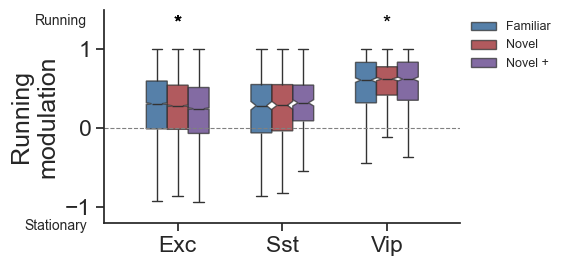

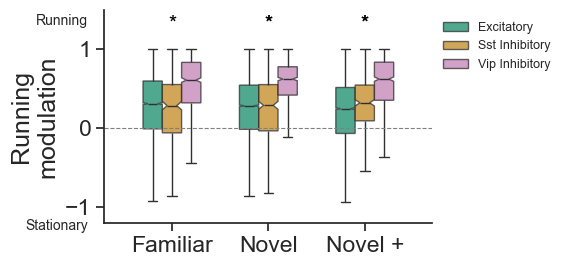

In [51]:
# Single-axis view: cell type on x, experience level as hue
ppf.plot_rmi_distribution_single_axis(
    cell_metrics, x_col='cell_type', hue_col='experience_level', save_dir=save_dir,
)

# Same data, axes swapped: experience level on x, cell type as hue
ppf.plot_rmi_distribution_single_axis(
    cell_metrics, x_col='experience_level', hue_col='cell_type', save_dir=save_dir,
)


array([<Axes: ylabel='Running modulation index'>, <Axes: >, <Axes: >],
      dtype=object)

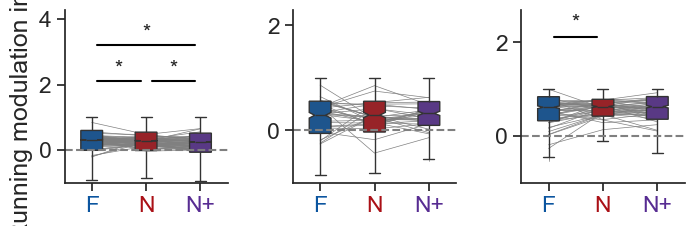

In [19]:
ppf.plot_metric_distribution_by_experience(cell_metrics, 'running_modulation_all_images', 'image', 'events', hue=None,
                                               plot_type='boxplot', legend=False, show_containers=True, estimator=np.mean,
                                               add_zero_line=True, show_ns=False, ylabel='Running modulation index', 
                                               ylims=(-1,2), horiz=True, abbreviate_exp=True, suptitle=None, 
                                               save_dir=None, folder='response_metrics', ax=None, suffix='',
                                               group_column='mouse_id')

In [20]:
# Pick a Vip cell with high (but not boundary) RMI as the initial example
RMI_BOUNDARY = 0.99  # exclude cells where one condition has ~zero mean (|RMI| >= boundary)

example_candidates = vip_cells[vip_cells['running_modulation_all_images'].abs() < RMI_BOUNDARY]
example_row = example_candidates.iloc[0]
example_csid = int(example_row['cell_specimen_id'])
example_oeid = int(example_row['ophys_experiment_id'])
example_rmi = float(example_row['running_modulation_all_images'])
print(f'example Vip cell: csid={example_csid}, oeid={example_oeid}, RMI={example_rmi:.3f}')


example Vip cell: csid=1086632371, oeid=1071070929, RMI=0.986


In [21]:
# Load sdf for the example experiment once; we'll filter to individual cells below
example_dataset = loading.get_ophys_dataset(example_oeid)
example_sdf = loading.get_stimulus_response_df(
    example_dataset,
    time_window=[-2, 2.1],
    interpolate=True,
    output_sampling_rate=30,
    data_type='events',
    event_type='all',
    load_from_file=True,
)
print('loaded sdf for experiment', example_oeid)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

file exists:
loading response df from file for 1071070929 events all
sdf loaded
loaded sdf for experiment 1071070929


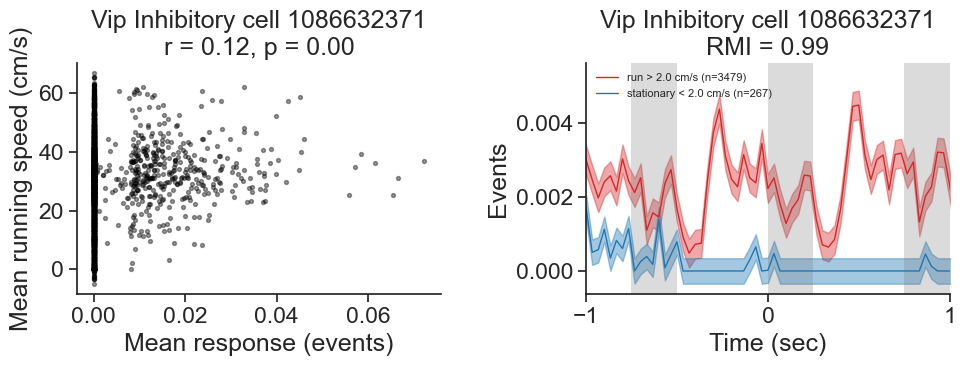

In [22]:
# Plot the initial example cell (function lives in pse)
fig, (r, p) = pse.plot_running_example_cell(
    example_sdf, example_csid, 'Vip Inhibitory', example_rmi,
    save_dir=save_dir, save_name=f'presaved_rmi_example_vip_{example_csid}',
)
plt.show()


### Top 3 high RMI + bottom 3 low RMI Vip cells from the same session

Pulls from the same `ophys_experiment_id` as the initial example so we reuse the loaded sdf. Already filtered for responsiveness (cell 12) and `|RMI| < RMI_BOUNDARY`.


8 responsive Vip cells in experiment 1071070929

Top 3 high RMI:
       cell_specimen_id  running_modulation_all_images  \
22224        1086632371                       0.986139   
22200        1086630685                       0.944970   
22223        1086631720                       0.941021   

       fraction_significant_p_value_gray_screen_all_images  
22224                                           0.109099    
22200                                           0.203536    
22223                                           0.122251    

Bottom 3 low RMI:
       cell_specimen_id  running_modulation_all_images  \
22203        1086632005                       0.848105   
22221        1086631455                       0.727331   
22219        1086631205                       0.306812   

       fraction_significant_p_value_gray_screen_all_images  
22203                                           0.182622    
22221                                           0.100259    
22219                  

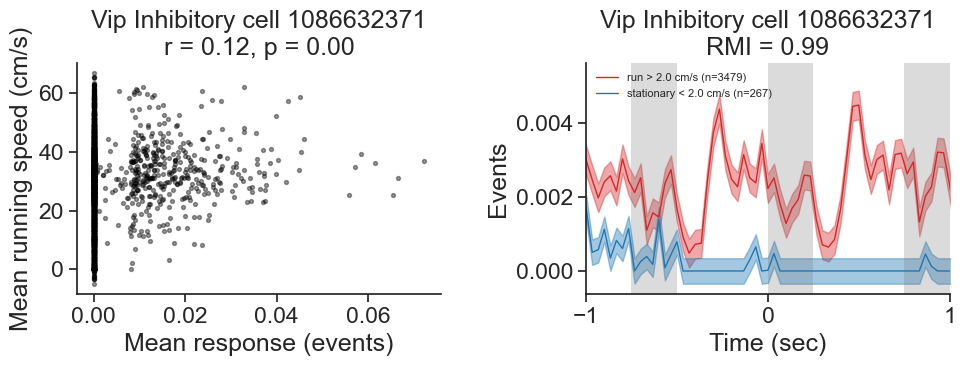

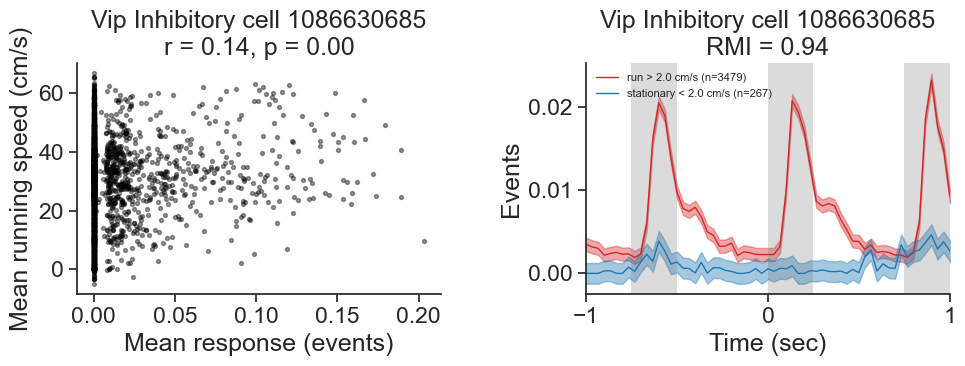

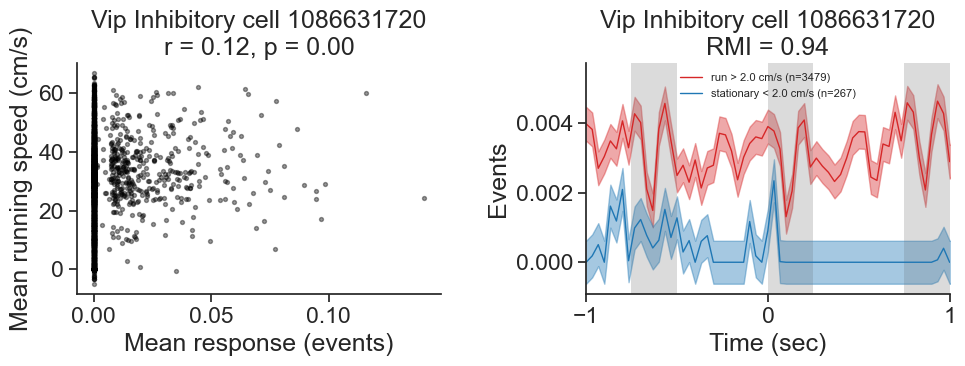

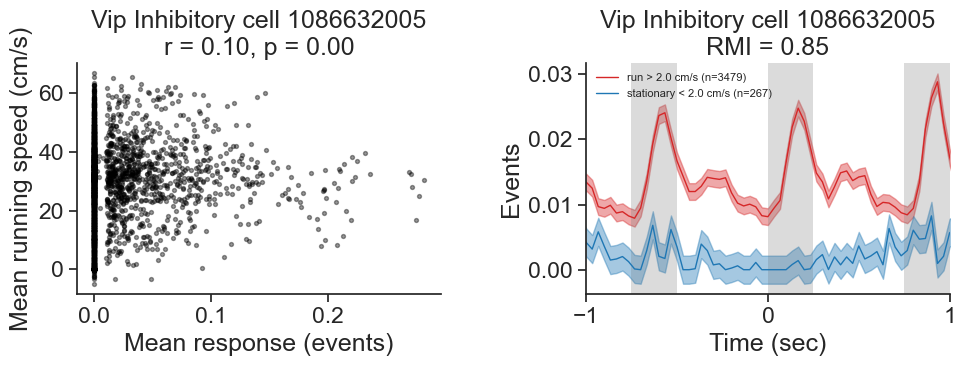

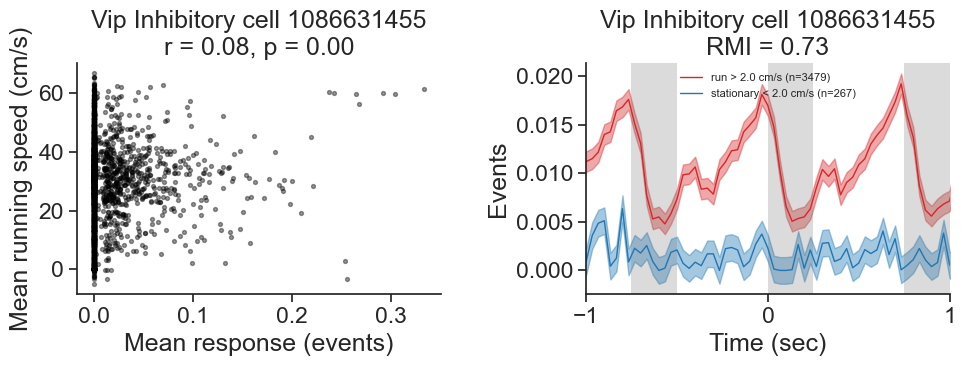

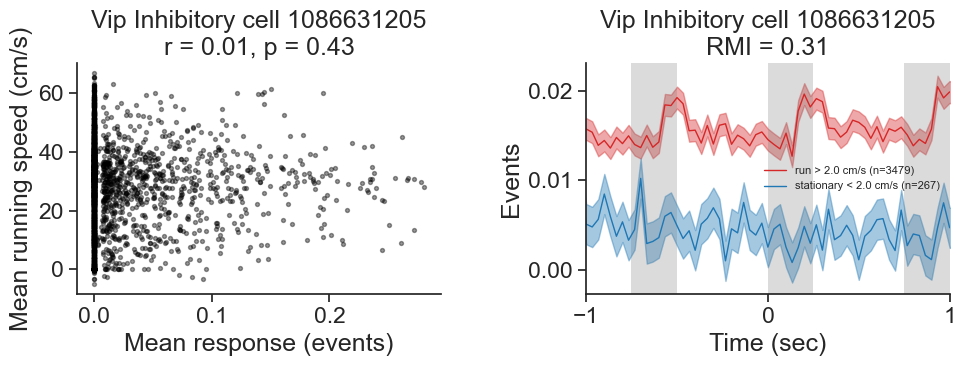

In [23]:
# Pull responsive Vip cells from the same experiment as the initial example
session_vip = vip_cells[
    (vip_cells.ophys_experiment_id == example_oeid)
    & (vip_cells['running_modulation_all_images'].abs() < RMI_BOUNDARY)
].copy()
session_vip = session_vip.sort_values('running_modulation_all_images', ascending=False)
print(len(session_vip), 'responsive Vip cells in experiment', example_oeid)

top3 = session_vip.head(3)
bottom3 = session_vip.tail(3)
print('\nTop 3 high RMI:')
print(top3[['cell_specimen_id', 'running_modulation_all_images',
            'fraction_significant_p_value_gray_screen_all_images']])
print('\nBottom 3 low RMI:')
print(bottom3[['cell_specimen_id', 'running_modulation_all_images',
               'fraction_significant_p_value_gray_screen_all_images']])

for label, group in [('high', top3), ('low', bottom3)]:
    for _, row in group.iterrows():
        csid = int(row['cell_specimen_id'])
        rmi = float(row['running_modulation_all_images'])
        pse.plot_running_example_cell(
            example_sdf, csid, 'Vip Inhibitory', rmi,
            save_dir=save_dir,
            save_name=f'presaved_rmi_{label}_vip_{csid}',
        )
        plt.show()


## Get data for all experiments

Loads pre-saved running_metrics_table.csv containing the running_modulation_index and trial by trial correlation of neural activity with running for each cell. Computed by notebook `generate_running_correlation_metrics.ipynb`


In [60]:
metrics_dir = loading.get_cell_metrics_dir()
running_metrics_filepath = os.path.join(metrics_dir, 'running_metrics_table.csv')
if os.path.exists(running_metrics_filepath):
    running_metrics_table = pd.read_csv(running_metrics_filepath, index_col=0)
    print('loaded running metrics table from', running_metrics_filepath)
else:
    print('running metrics table not found at', running_metrics_filepath)
    print('please run visual_behavior.notebooks.platform_paper_figures.compute_running_metrics_table to compute and save the table')

loaded running metrics table from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_analysis_files/cell_metrics/running_metrics_table.csv


In [61]:
# Merge cre_line + experience_level from the platform_experiments table; derive cell_type from cre_line
metrics_table = running_metrics_table.merge(
    platform_experiments[['cell_type', 'experience_level', 'mouse_id', 'ophys_container_id', 'behavior_session_id']].reset_index(),
    on='ophys_experiment_id',
    how='left',)

print(metrics_table[['cell_type', 'experience_level']].value_counts())

cell_type       experience_level
Excitatory      Novel               7974
                Novel +             7404
                Familiar            7302
Vip Inhibitory  Familiar             794
                Novel +              765
                Novel                718
Sst Inhibitory  Novel                337
                Familiar             321
                Novel +              320
dtype: int64


#### Distribution of correlation values

In [64]:
metrics_table.columns

Index(['cell_specimen_id', 'activity_running_corr', 'activity_running_pval',
       'running_modulation_index', 'mean_response_run',
       'mean_response_stationary', 'n_run_trials', 'n_stationary_trials',
       'n_trials_total', 'ophys_experiment_id', 'cell_type',
       'experience_level', 'mouse_id', 'ophys_container_id',
       'behavior_session_id'],
      dtype='object')

<Axes: ylabel='Running\nmodulation'>

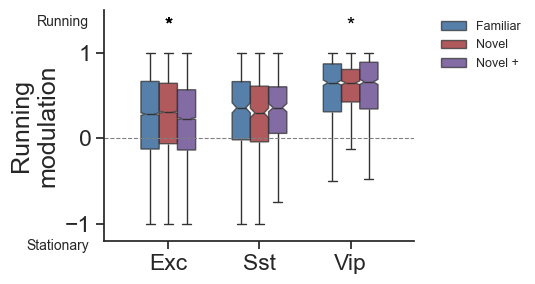

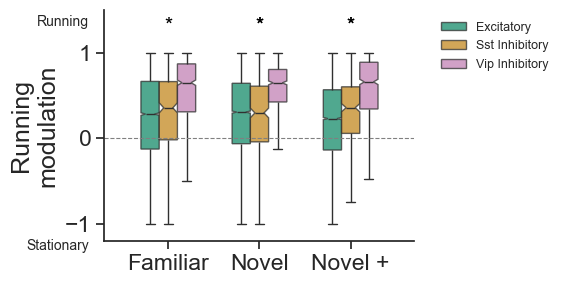

In [71]:
# Single-axis view: cell type on x, experience level as hue
ppf.plot_rmi_distribution_single_axis(metrics_table, metric='running_modulation_index',
    x_col='cell_type', hue_col='experience_level', save_dir=save_dir,
)

# Same data, axes swapped: experience level on x, cell type as hue
ppf.plot_rmi_distribution_single_axis(metrics_table, metric='running_modulation_index',
                                      x_col='experience_level', hue_col='cell_type', save_dir=save_dir,
)


<Axes: ylabel='Activity vs.running\ncorrelation (pearson r)'>

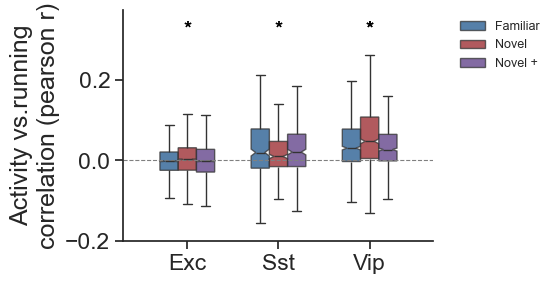

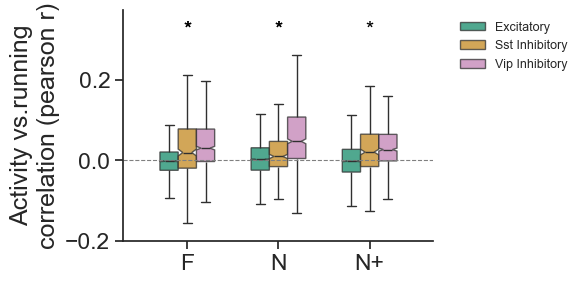

In [72]:
ylims = (-0.2, 0.3)

ppf.plot_correlation_distribution_single_axis(
    metrics_table, x_col='cell_type', hue_col='experience_level', ylims=ylims,
    save_dir=save_dir, save_name='activity_running_corr_celltype_and_experience_hue',
)
ppf.plot_correlation_distribution_single_axis(
    metrics_table, x_col='experience_level', hue_col='cell_type', ylims=ylims,
    save_dir=save_dir, save_name='activity_running_corr_experience_and_celltype_hue',
)

### Top 6 high RMI + bottom 3 low RMI Vip cells from one session (from metrics_table)

Pick a primary Vip example with high RMI from `metrics_table`, load its experiment's sdf once, then preview 9 candidate cells (6 high RMI, 3 low RMI) from the same session so we can choose a good single-cell example without re-loading sdfs.

Uses `plot_running_example_cell` defined in the pre-saved-RMI section above — run that cell first.


In [59]:
# Pick primary Vip example from metrics_table (highest RMI, with trial-count and boundary filters)
MT_MIN_TRIALS = 30
MT_RMI_BOUNDARY = 0.99

mt_vip = metrics_table[
    (metrics_table.cell_type == 'Vip Inhibitory')
    & (metrics_table.n_run_trials >= MT_MIN_TRIALS)
    & (metrics_table.n_stationary_trials >= MT_MIN_TRIALS)
    & (metrics_table.running_modulation_index.abs() < MT_RMI_BOUNDARY)
].copy()
mt_vip = mt_vip.sort_values('running_modulation_index', ascending=False)
print(len(mt_vip), 'eligible Vip cells across all sessions')

mt_example_row = mt_vip.iloc[0]
mt_example_csid = int(mt_example_row['cell_specimen_id'])
mt_example_oeid = int(mt_example_row['ophys_experiment_id'])
mt_example_rmi = float(mt_example_row['running_modulation_index'])
print(f'primary Vip example: csid={mt_example_csid}, oeid={mt_example_oeid}, RMI={mt_example_rmi:.3f}')

# Load sdf for that experiment once
mt_example_dataset = loading.get_ophys_dataset(mt_example_oeid)
mt_example_sdf = loading.get_stimulus_response_df(
    mt_example_dataset,
    time_window=[-2, 2.1],
    interpolate=True,
    output_sampling_rate=30,
    data_type='events',
    event_type='all',
    load_from_file=True,
)
print('loaded sdf for experiment', mt_example_oeid)


1942 eligible Vip cells across all sessions
primary Vip example: csid=1086673608, oeid=848760990, RMI=0.987


EndpointConnectionError: Could not connect to the endpoint URL: "https://visual-behavior-ophys-data.s3.amazonaws.com/?list-type=2&prefix=visual-behavior-ophys%2Fmanifests%2F&encoding-type=url"

17 eligible Vip cells in experiment 848760990

Top 6 high RMI:
      cell_specimen_id  running_modulation_index  activity_running_corr  \
9472        1086673608                  0.986735               0.058461   
9457        1086673209                  0.984137               0.044638   
9466        1086673402                  0.952810               0.077784   
9464        1086673376                  0.920058               0.029656   
9469        1086673561                  0.861003               0.066718   
9453        1086673085                  0.776839               0.040546   

      activity_running_pval  
9472               0.000890  
9457               0.011200  
9466               0.000010  
9464               0.092054  
9469               0.000149  
9453               0.021239  

Bottom 3 low RMI:
      cell_specimen_id  running_modulation_index  activity_running_corr  \
9455        1086673159                 -0.670580              -0.032066   
9463        1086673356          

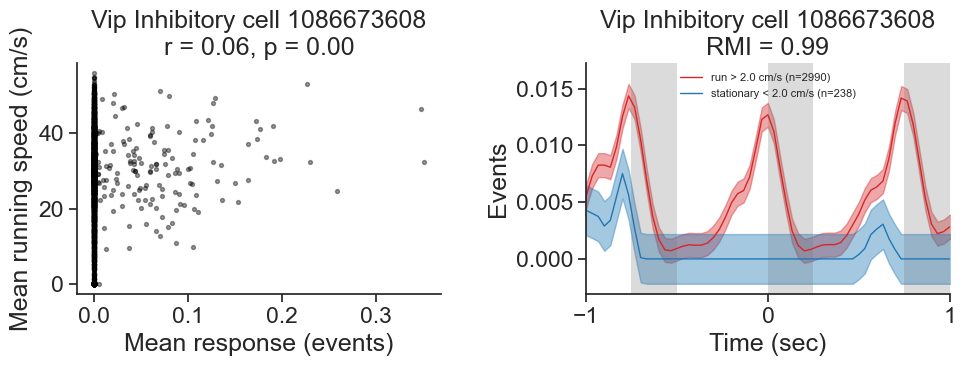

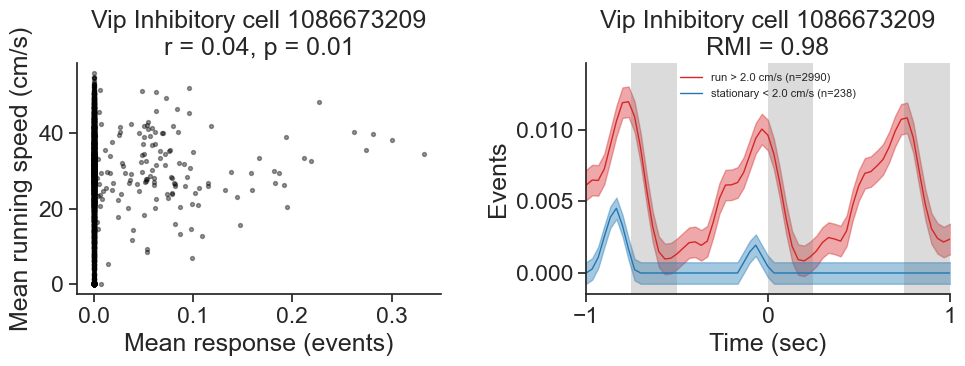

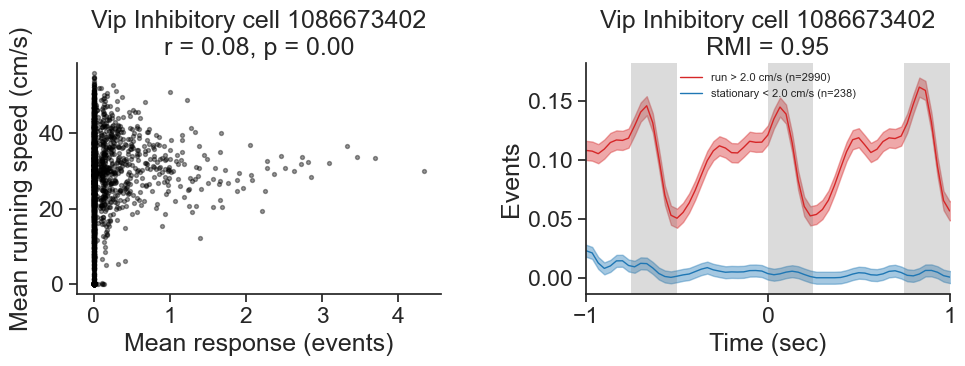

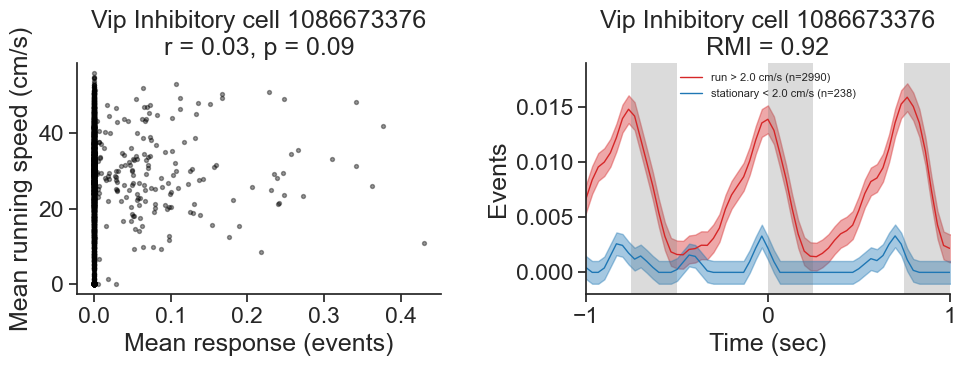

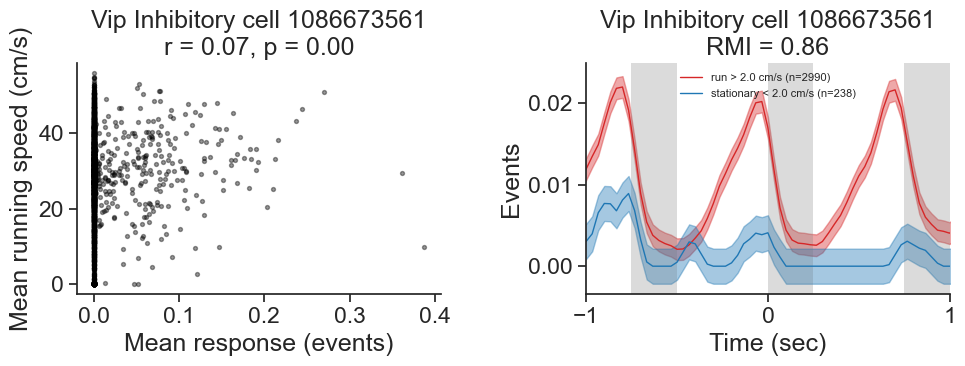

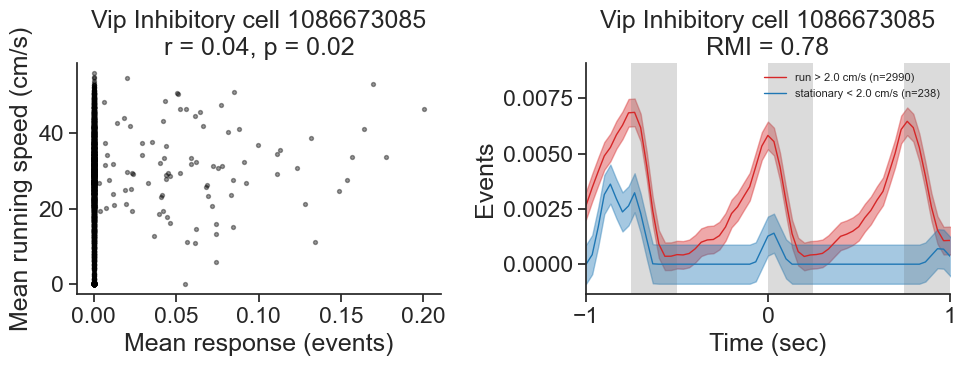

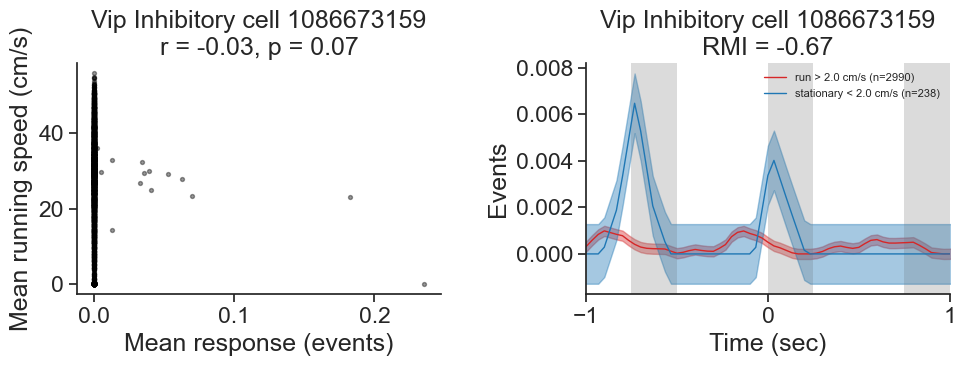

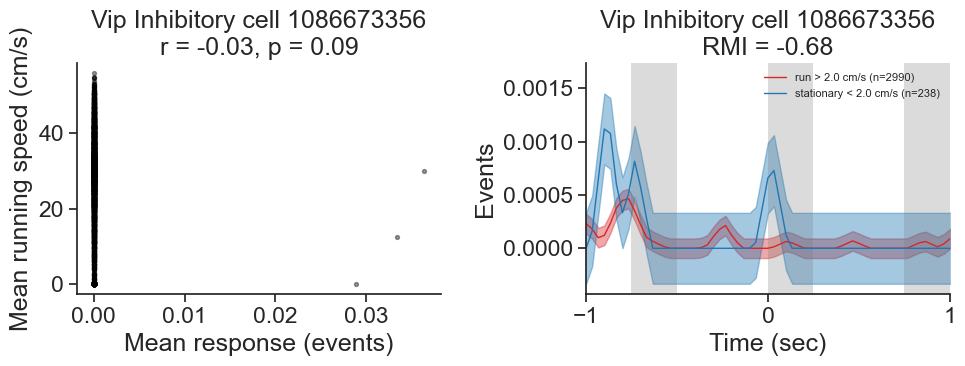

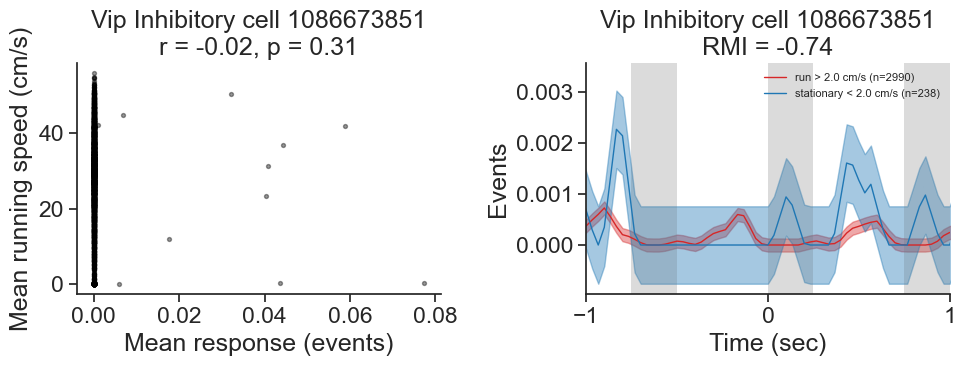

In [ ]:
# Top 6 high RMI + bottom 3 low RMI Vip cells from the same session
session_vip = mt_vip[mt_vip.ophys_experiment_id == mt_example_oeid].copy()
session_vip = session_vip.sort_values('running_modulation_index', ascending=False)
print(len(session_vip), 'eligible Vip cells in experiment', mt_example_oeid)

top6 = session_vip.head(6)
bottom3 = session_vip.tail(3)
print('\nTop 6 high RMI:')
print(top6[['cell_specimen_id', 'running_modulation_index',
            'activity_running_corr', 'activity_running_pval']])
print('\nBottom 3 low RMI:')
print(bottom3[['cell_specimen_id', 'running_modulation_index',
               'activity_running_corr', 'activity_running_pval']])

for label, group in [('high', top6), ('low', bottom3)]:
    for _, row in group.iterrows():
        csid = int(row['cell_specimen_id'])
        rmi = float(row['running_modulation_index'])
        pse.plot_running_example_cell(
            mt_example_sdf, csid, 'Vip Inhibitory', rmi,
            save_dir=save_dir,
            save_name=f'metrics_table_rmi_{label}_vip_{csid}',
        )
        plt.show()


### Top 6 / bottom 3 activity-running correlation Vip cells from one session

Same idea as the RMI loop above but ranked by `activity_running_corr` (with significant p<0.05). Reuses `mt_example_sdf` if from the same experiment; otherwise loads a new sdf.


In [ ]:
# Pick primary Vip example by correlation (sig p, with trial-count and boundary filters)
MT_CORR_PVAL_THRESH = 0.05

mt_vip_corr = metrics_table[
    (metrics_table.cell_type == 'Vip Inhibitory')
    & (metrics_table.n_run_trials >= MT_MIN_TRIALS)
    & (metrics_table.n_stationary_trials >= MT_MIN_TRIALS)
    & (metrics_table.running_modulation_index.abs() < MT_RMI_BOUNDARY)
    & (metrics_table.activity_running_pval < MT_CORR_PVAL_THRESH)
].copy()
mt_vip_corr = mt_vip_corr.sort_values('activity_running_corr', ascending=False)
print(len(mt_vip_corr), 'eligible Vip cells (sig p) across all sessions')

mt_corr_example_row = mt_vip_corr.iloc[0]
mt_corr_example_csid = int(mt_corr_example_row['cell_specimen_id'])
mt_corr_example_oeid = int(mt_corr_example_row['ophys_experiment_id'])
mt_corr_example_r = float(mt_corr_example_row['activity_running_corr'])
print(f'primary Vip example: csid={mt_corr_example_csid}, oeid={mt_corr_example_oeid}, r={mt_corr_example_r:.3f}')

# Reuse mt_example_sdf if it's the same experiment, otherwise load
if 'mt_example_sdf' in dir() and mt_corr_example_oeid == mt_example_oeid:
    mt_corr_example_sdf = mt_example_sdf
    print('reusing mt_example_sdf from RMI section')
else:
    _ds = loading.get_ophys_dataset(mt_corr_example_oeid)
    mt_corr_example_sdf = loading.get_stimulus_response_df(
        _ds, time_window=[-2, 2.1], interpolate=True, output_sampling_rate=30,
        data_type='events', event_type='all', load_from_file=True,
    )
    print('loaded sdf for experiment', mt_corr_example_oeid)


1228 eligible Vip cells (sig p) across all sessions
primary Vip example: csid=1086514113, oeid=953443028, r=0.591


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

generating response df


100%|██████████| 14/14 [00:04<00:00,  3.36it/s]
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:843: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['trace', 'trace_timestamps', 'data_type', 'event_type'], dtype='object')]

  sdf.to_hdf(filepath, key='df')


saved response df to /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_stimulus_response_dfs/953443028_events_all.h5
loaded sdf for experiment 953443028


13 eligible Vip cells in experiment 953443028

Top 6 high corr:
       cell_specimen_id  activity_running_corr  activity_running_pval  \
16562        1086514113               0.590911           0.000000e+00   
16572        1086516497               0.567165          1.040123e-293   
16569        1086515627               0.524429          9.542133e-244   
16563        1086514265               0.486124          1.150992e-204   
16565        1086514571               0.445648          1.927516e-168   
16574        1086516905               0.384185          4.636425e-122   

       running_modulation_index  
16562                  0.976681  
16572                  0.840913  
16569                  0.946400  
16563                  0.952322  
16565                  0.948471  
16574                  0.916224  

Bottom 3 low corr:
       cell_specimen_id  activity_running_corr  activity_running_pval  \
16571        1086516133               0.195628           3.510039e-31   
16566        1086514

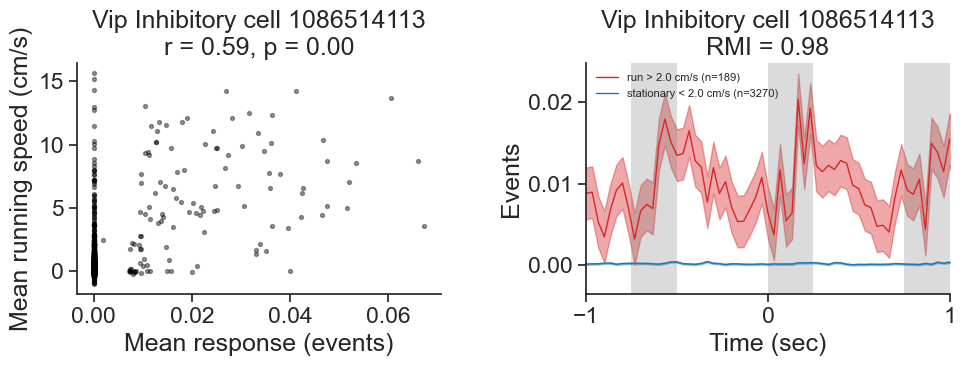

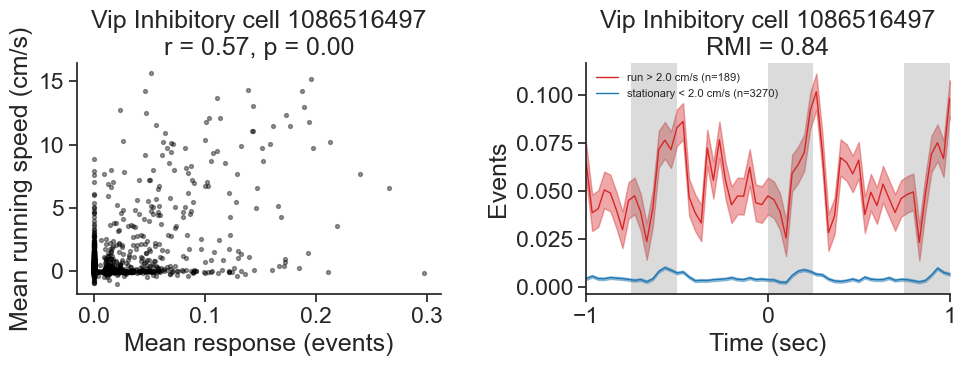

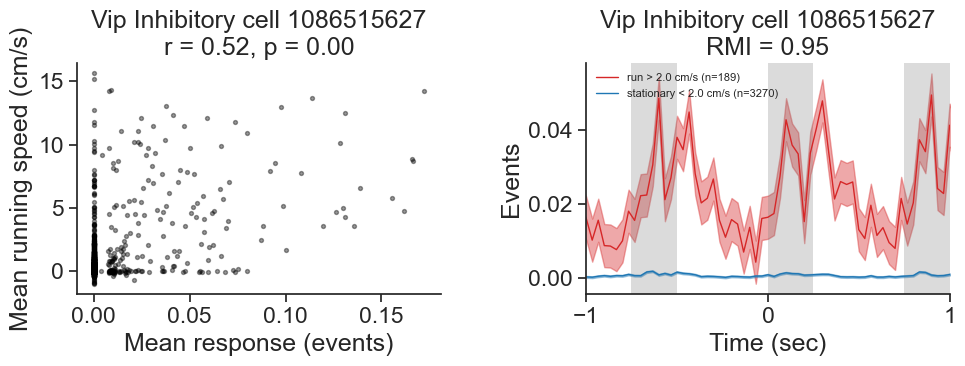

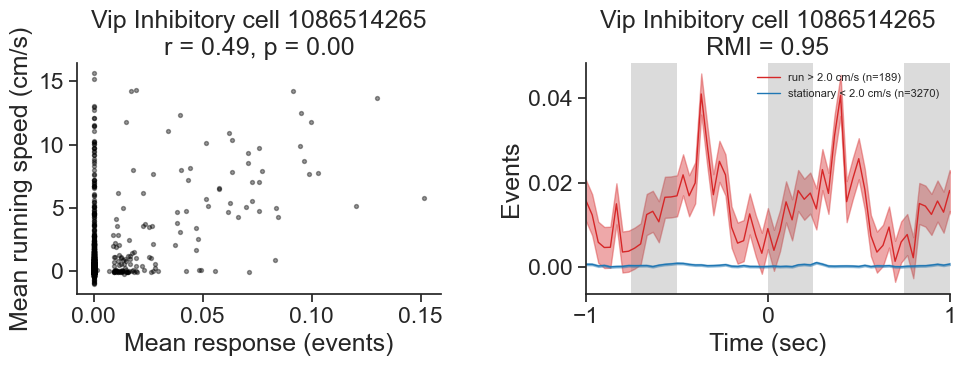

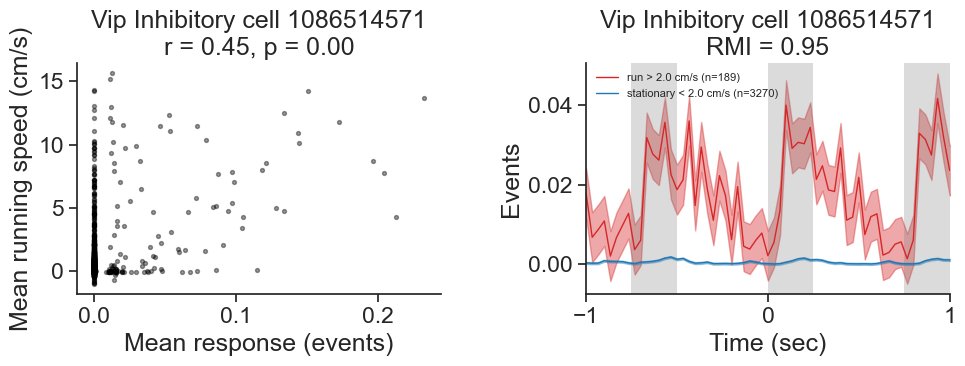

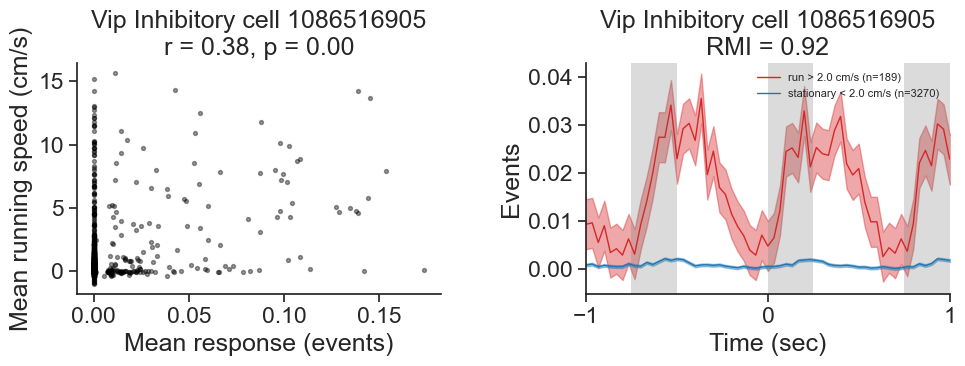

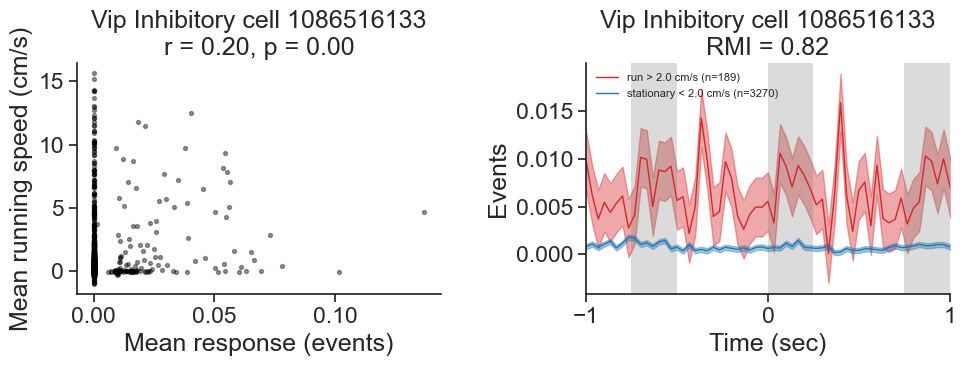

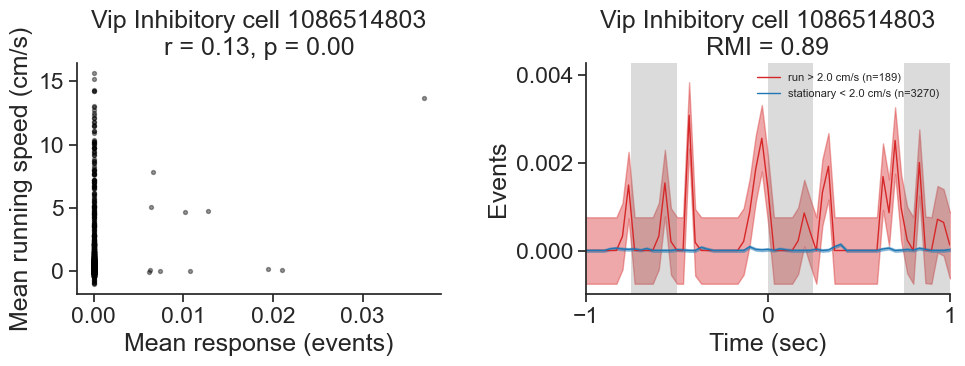

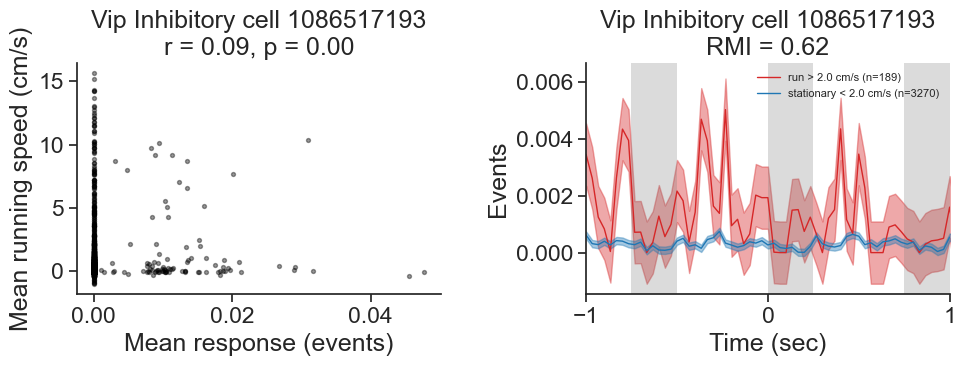

In [ ]:
# Top 6 high corr + bottom 3 low corr Vip cells (sig p) from the same session
session_vip_corr = mt_vip_corr[mt_vip_corr.ophys_experiment_id == mt_corr_example_oeid].copy()
session_vip_corr = session_vip_corr.sort_values('activity_running_corr', ascending=False)
print(len(session_vip_corr), 'eligible Vip cells in experiment', mt_corr_example_oeid)

top6_corr = session_vip_corr.head(6)
bottom3_corr = session_vip_corr.tail(3)
print('\nTop 6 high corr:')
print(top6_corr[['cell_specimen_id', 'activity_running_corr',
                 'activity_running_pval', 'running_modulation_index']])
print('\nBottom 3 low corr:')
print(bottom3_corr[['cell_specimen_id', 'activity_running_corr',
                    'activity_running_pval', 'running_modulation_index']])

for label, group in [('high', top6_corr), ('low', bottom3_corr)]:
    for _, row in group.iterrows():
        csid = int(row['cell_specimen_id'])
        rmi = float(row['running_modulation_index'])
        pse.plot_running_example_cell(
            mt_corr_example_sdf, csid, 'Vip Inhibitory', rmi,
            save_dir=save_dir,
            save_name=f'metrics_table_corr_{label}_vip_{csid}',
        )
        plt.show()


## Single-cell examples

Pick one Vip cell with a high activity-running correlation, and one with a high running modulation index.
Only consider cells with adequate trial counts in both running conditions.

In [ ]:
MIN_TRIALS_FOR_EXAMPLES = 30  # per condition
PVAL_THRESH = 0.05
RMI_BOUNDARY_BUFFER = 0.01  # exclude cells with |RMI| >= 1 - buffer (one condition had ~zero mean)

vip = metrics_table[
    (metrics_table.cell_type == 'Vip Inhibitory')
    & (metrics_table.n_run_trials >= MIN_TRIALS_FOR_EXAMPLES)
    & (metrics_table.n_stationary_trials >= MIN_TRIALS_FOR_EXAMPLES)
    & (metrics_table.running_modulation_index.abs() < 1 - RMI_BOUNDARY_BUFFER)
].copy()

# Pick top by correlation, requiring a significant fit
high_corr_row = (
    vip[vip.activity_running_pval < PVAL_THRESH]
    .sort_values('activity_running_corr', ascending=False)
    .iloc[0]
)
# Pick top by RMI (boundary cells already excluded above)
high_rmi_row = vip.sort_values('running_modulation_index', ascending=False).iloc[0]

print('high-corr Vip cell:')
print(high_corr_row[['cell_specimen_id', 'ophys_experiment_id', 'activity_running_corr',
                     'activity_running_pval', 'running_modulation_index']])
print('\nhigh-RMI Vip cell:')
print(high_rmi_row[['cell_specimen_id', 'ophys_experiment_id', 'activity_running_corr',
                    'activity_running_pval', 'running_modulation_index']])


high-corr Vip cell:
cell_specimen_id            1086514113
ophys_experiment_id          953443028
activity_running_corr         0.590911
activity_running_pval              0.0
running_modulation_index      0.976681
Name: 16562, dtype: object

high-RMI Vip cell:
cell_specimen_id            1086673608
ophys_experiment_id          848760990
activity_running_corr         0.058461
activity_running_pval          0.00089
running_modulation_index      0.986735
Name: 9472, dtype: object


In [ ]:
def get_cell_sdf(ophys_experiment_id, cell_specimen_id):
    """Reload stimulus_response_df for one experiment and filter to a single cell."""
    dataset = loading.get_ophys_dataset(ophys_experiment_id)
    sdf = loading.get_stimulus_response_df(
        dataset,
        time_window=[-2, 2.1],
        interpolate=True,
        output_sampling_rate=30,
        data_type='events',
        event_type='all',
        load_from_file=True,
    )
    cell_sdf = sdf[sdf.cell_specimen_id == cell_specimen_id].copy()
    return filter_steady_state_presentations(cell_sdf)

In [ ]:
def plot_response_vs_running_scatter(cell_sdf, csid, cell_type, r, p, ax=None, save_name=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(cell_sdf['mean_response'], cell_sdf['mean_running_speed'],
               s=8, alpha=0.4, color='k')
    ax.set_xlabel('Mean response (events)')
    ax.set_ylabel('Mean running speed (cm/s)')
    title = f'{cell_type} cell {csid}\nr = {r:.2f}, p = {p:.2f}'
    ax.set_title(title)
    sns.despine(ax=ax)
    if save_name is not None:
        plt.gcf().savefig(os.path.join(save_dir, save_name + '.png'), dpi=200, bbox_inches='tight')
        plt.gcf().savefig(os.path.join(save_dir, save_name + '.pdf'), bbox_inches='tight')
    return ax


def plot_run_vs_stationary_traces(cell_sdf, csid, cell_type, rmi, run_thresh=RUN_THRESH,
                              ax=None, save_name=None):
    run_df = cell_sdf[cell_sdf['mean_running_speed'] > run_thresh]
    stationary_df = cell_sdf[cell_sdf['mean_running_speed'] < run_thresh]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.5))
    ax = utils.plot_stimulus_response_df_trace(
        run_df, time_window=[-1, 1], change=False, omitted=False,
        ylabel='Events', legend_label=f'run > {run_thresh} cm/s (n={len(run_df)})',
        color='tab:red', ax=ax,
    )
    ax = utils.plot_stimulus_response_df_trace(
        stationary_df, time_window=[-1, 1], change=False, omitted=False,
        ylabel='Events', legend_label=f'run < {run_thresh} cm/s (n={len(stationary_df)})',
        color='tab:blue', ax=ax,
    )
    ax.legend(fontsize=8, frameon=False)
    title = f'{cell_type} cell {csid}\nrunning modulation index = {rmi:.2f}'
    ax.set_title(title)
    if save_name is not None:
        plt.gcf().savefig(os.path.join(save_dir, save_name + '.png'), dpi=200, bbox_inches='tight')
        plt.gcf().savefig(os.path.join(save_dir, save_name + '.pdf'), bbox_inches='tight')
    return ax

### High activity-running correlation Vip cell

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

file exists:
loading response df from file for 953443028 events all
sdf loaded
3459 stimulus presentations


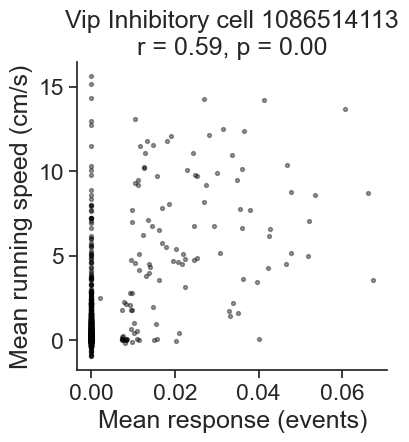

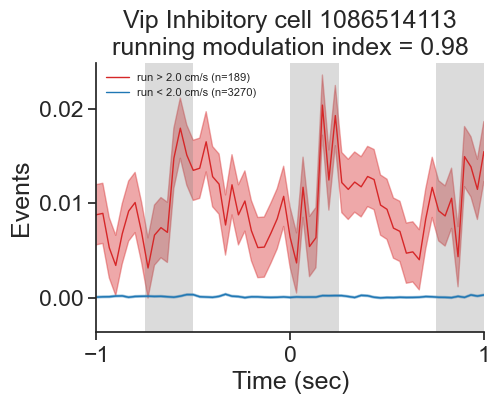

In [ ]:
csid = int(high_corr_row['cell_specimen_id'])
oeid = int(high_corr_row['ophys_experiment_id'])
cell_sdf_corr = get_cell_sdf(oeid, csid)
print(len(cell_sdf_corr), 'stimulus presentations')

plot_response_vs_running_scatter(
    cell_sdf_corr, csid, 'Vip Inhibitory',
    r=high_corr_row['activity_running_corr'],
    p=high_corr_row['activity_running_pval'],
    save_name=f'scatter_high_corr_vip_{csid}',
)
plt.show()

plot_run_vs_stationary_traces(
    cell_sdf_corr, csid, 'Vip Inhibitory',
    rmi=high_corr_row['running_modulation_index'],
    save_name=f'traces_high_corr_vip_{csid}',
)
plt.show()

### High running modulation index Vip cell

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

file exists:
loading response df from file for 848760990 events all
sdf loaded
3228 stimulus presentations


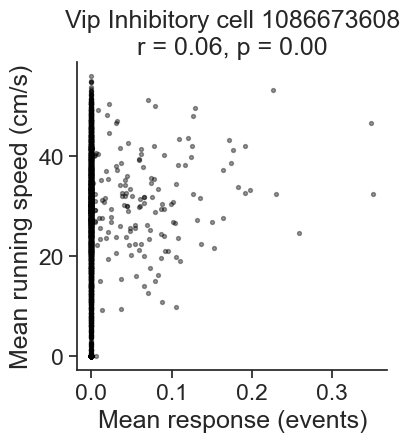

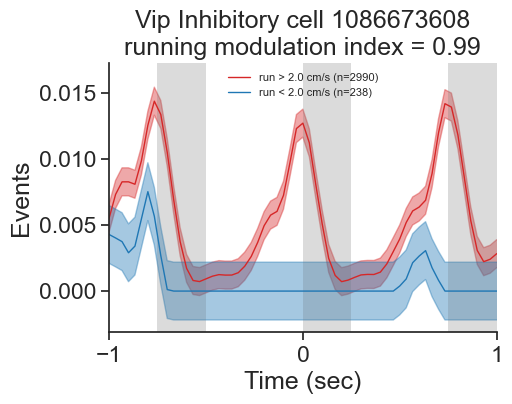

In [ ]:
csid = int(high_rmi_row['cell_specimen_id'])
oeid = int(high_rmi_row['ophys_experiment_id'])
cell_sdf_rmi = get_cell_sdf(oeid, csid)
print(len(cell_sdf_rmi), 'stimulus presentations')

plot_response_vs_running_scatter(
    cell_sdf_rmi, csid, 'Vip Inhibitory',
    r=high_rmi_row['activity_running_corr'],
    p=high_rmi_row['activity_running_pval'],
    save_name=f'scatter_high_rmi_vip_{csid}',
)
plt.show()

plot_run_vs_stationary_traces(
    cell_sdf_rmi, csid, 'Vip Inhibitory',
    rmi=high_rmi_row['running_modulation_index'],
    save_name=f'traces_high_rmi_vip_{csid}',
)
plt.show()

## Change in Neural Activity vs. Change in Behavior

Scatter plots showing the relationship between the change in neural response metrics
(Familiar to Novel) vs. the change in behavioral metrics (running speed, pupil width,
d-prime) across mice. Each point is one mouse, split by cell type.

Source: `251202_compare_behavior_and_novelty_response.ipynb` cells 65-80

#### Load cell metrics

In [ ]:
data_type = 'filtered_events'
session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

metrics_dir = loading.get_cell_metrics_dir()
filepath = os.path.join(metrics_dir, f'merged_model_free_metrics_table_{data_type}_{inclusion_criteria}.csv')
filtered_events_metrics_table = pd.read_csv(filepath, index_col=0)

metrics_table = filtered_events_metrics_table.copy()

# Merge with platform experiments
metrics_table = metrics_table.merge(platform_experiments.reset_index(),
                                   on=['ophys_experiment_id', 'experience_level'])


#### Load behavior metrics

In [ ]:
# Drop metrics cols because we will get them elsewhere
from visual_behavior.data_access import utilities


cols_to_drop = ['engaged_trial_count',
       'false_alarm_trial_count', 'trial_count', 'go_trial_count',
       'correct_reject_trial_count', 'catch_trial_count', 'file_id',
       'hit_trial_count', 'miss_trial_count',]

# Only mice included in this study (i.e. excluding project code VisualBehaviorMultiscope4areasx2d)
# platform_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_behavior_sessions_table.csv'), index_col=0)
# platform_behavior_sessions = platform_behavior_sessions.drop(columns=cols_to_drop)
# platform_behavior_sessions = utilities.add_behavior_stage_to_behavior_sessions(platform_behavior_sessions)
# platform_behavior_sessions['mouse_id'] = [int(mouse_id) for mouse_id in platform_behavior_sessions.mouse_id.values]

# Limited to sessions with ophys data
platform_ophys_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_ophys_behavior_sessions_table.csv'), index_col=0)
platform_ophys_behavior_sessions = platform_ophys_behavior_sessions.drop(columns=cols_to_drop)
platform_ophys_behavior_sessions['mouse_id'] = [int(mouse_id) for mouse_id in platform_ophys_behavior_sessions.mouse_id.values]

# Save to more convenient name
behavior_sessions = platform_ophys_behavior_sessions.copy()

In [ ]:
import visual_behavior.utilities as vbu


In [ ]:
behavior_metrics_dir = loading.get_performance_metrics_dir()

# Behavior metrics computed by AllenSDK
behavior_stats_sdk = pd.read_hdf(os.path.join(behavior_metrics_dir, 'sdk_all_sessions.h5'), key='data')
behavior_stats_sdk.index.name = 'behavior_session_id'
behavior_stats_sdk = behavior_stats_sdk.reset_index()  # move behavior_session_id from index to column
behavior_stats_sdk = behavior_stats_sdk.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice 
behavior_stats_sdk = behavior_stats_sdk[behavior_stats_sdk.mouse_id.isin(behavior_sessions.mouse_id.unique())]
behavior_stats_sdk['mouse_id'] = [int(mouse_id) for mouse_id in behavior_stats_sdk.mouse_id.values]

# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
engaged_behavior_stats_stim = pd.read_hdf(os.path.join(behavior_metrics_dir, 'stimulus_based_engaged_only_all_sessions.h5'), key='data')
engaged_behavior_stats_stim = engaged_behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice 
engaged_behavior_stats_stim = engaged_behavior_stats_stim[engaged_behavior_stats_stim.behavior_session_id.isin(behavior_sessions.index.unique())]


# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
behavior_stats_stim = pd.read_hdf(os.path.join(behavior_metrics_dir, 'stimulus_based_all_sessions.h5'), key='data')
behavior_stats_stim = behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice 
behavior_stats_stim = behavior_stats_stim[behavior_stats_stim.behavior_session_id.isin(behavior_sessions.index.unique())]


# Load platform behavior stats for stimulus-based metrics
platform_behavior_stats = pd.read_csv(os.path.join(behavior_metrics_dir,  'platform_behavior_stats_engaged.csv'), index_col=0)
platform_behavior_stats = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice 
platform_behavior_stats = platform_behavior_stats[platform_behavior_stats.behavior_session_id.isin(behavior_sessions.index.unique())]


In [ ]:
# Get running speed metrics for each session
running_speed_mdf_images = loading.get_behavior_multi_session_df('running_speed', 'images', platform_experiments, epoch_duration_mins=None)
running_speed_mdf_changes = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=None)

running_speed_mdf_images['mouse_id'] = [int(mouse_id) for mouse_id in running_speed_mdf_images.mouse_id.values]
running_speed_mdf_changes['mouse_id'] = [int(mouse_id) for mouse_id in running_speed_mdf_changes.mouse_id.values]

# Average across mice for subsequent analysis
running_speed_mdf_changes['mean_run_speed_changes'] = running_speed_mdf_changes.mean_response
running_speed_mdf_images['mean_run_speed_images'] = running_speed_mdf_images.mean_response

condition_type = 'mean_run_speed_images'
running_metrics_images = running_speed_mdf_images.groupby(['mouse_id', 'cell_type', 'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()

condition_type = 'mean_run_speed_changes'
running_metrics_changes = running_speed_mdf_changes.groupby(['mouse_id', 'cell_type', 'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_platform_experiment_table.feather
there are 1880 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_platform_experiment_table.feather
there are 1880 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_21406/756690910.py:13: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  running_metrics_images = running_speed_mdf_images.groupby(['mouse_id', 'cell_type', 'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_21406/756690910.py:16: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  running_metrics_changes = running_speed_mdf_changes.groupby(['mouse_id', 'cell_type', 'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()


In [44]:
image_mdf = loading.get_behavior_multi_session_df('pupil_width', 'images', platform_experiments, epoch_duration_mins=None)
print(len(image_mdf.ophys_experiment_id.unique()), 'experiments')

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_pupil_width_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_pupil_width_all_is_change_platform_experiment_table.feather
there are 1876 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table
201 experiments


In [45]:
# Get pupil width metrics for each session
pupil_mdf_images = loading.get_behavior_multi_session_df('pupil_width', 'images', platform_experiments, epoch_duration_mins=None)
pupil_mdf_changes = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=None)

pupil_mdf_images['mouse_id'] = [int(mouse_id) for mouse_id in pupil_mdf_images.mouse_id.values]
pupil_mdf_changes['mouse_id'] = [int(mouse_id) for mouse_id in pupil_mdf_changes.mouse_id.values]

pupil_mdf_images['mean_pupil_width_images'] = pupil_mdf_images.mean_response
pupil_mdf_changes['mean_pupil_width_changes'] = pupil_mdf_changes.mean_response

condition_type = 'mean_pupil_width_images'
pupil_metrics_images = pupil_mdf_images.groupby(['mouse_id', 'cell_type' ,'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()

condition_type = 'mean_pupil_width_changes'
pupil_metrics_changes = pupil_mdf_changes.groupby(['mouse_id', 'cell_type' ,'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_pupil_width_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_pupil_width_all_is_change_platform_experiment_table.feather
there are 1876 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_pupil_width_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_pupil_width_all_is_change_platform_experiment_table.feather
there are 1876 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_21406/2789081838.py:12: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  pupil_metrics_images = pupil_mdf_images.groupby(['mouse_id', 'cell_type' ,'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_21406/2789081838.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  pupil_metrics_changes = pupil_mdf_changes.groupby(['mouse_id', 'cell_type' ,'experience_level', 'behavior_session_id']).median()[[condition_type]].reset_index()


#### Change in behavior vs. change in physio

##### Running speed

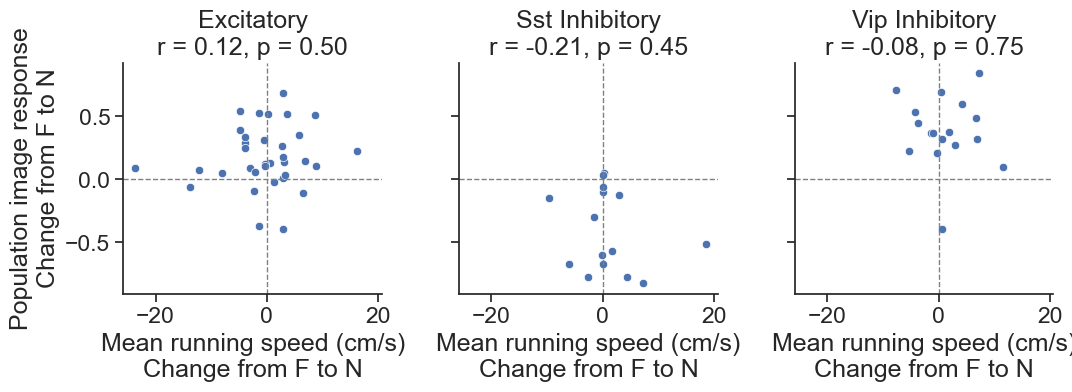

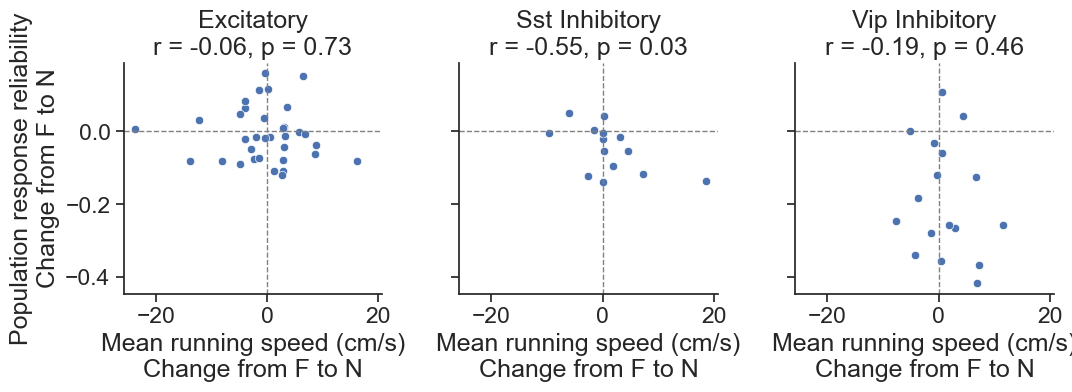

In [46]:
# Plot change in activity vs. change in running speed
behavior_metric = 'mean_run_speed_images'
behavior_label = 'Mean running speed (cm/s)'

suptitle = 'Change in neural activity vs change in running speed from familiar to novel sessions'


cell_metric = 'mean_response_pref_image'
metric_label = 'Population image response'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, running_metrics_images, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric, show_fit=False, 
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)



cell_metric = 'reliability_pref_image'
metric_label = 'Population response reliability'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, running_metrics_images, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric,
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)

##### Pupil width

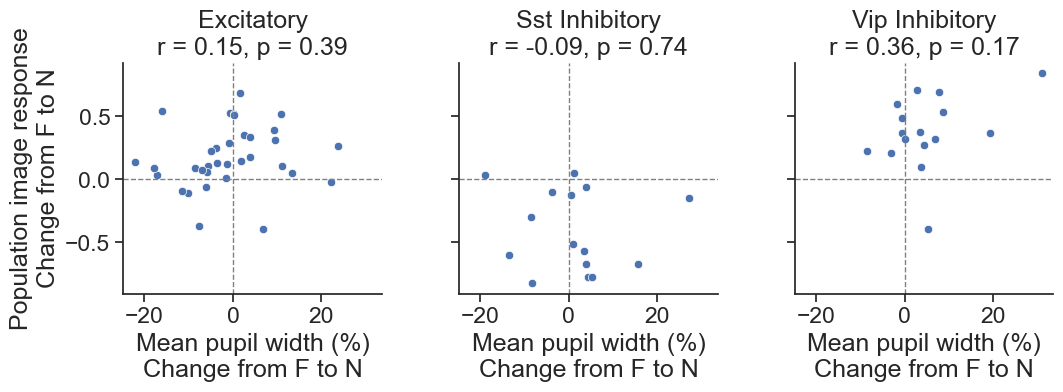

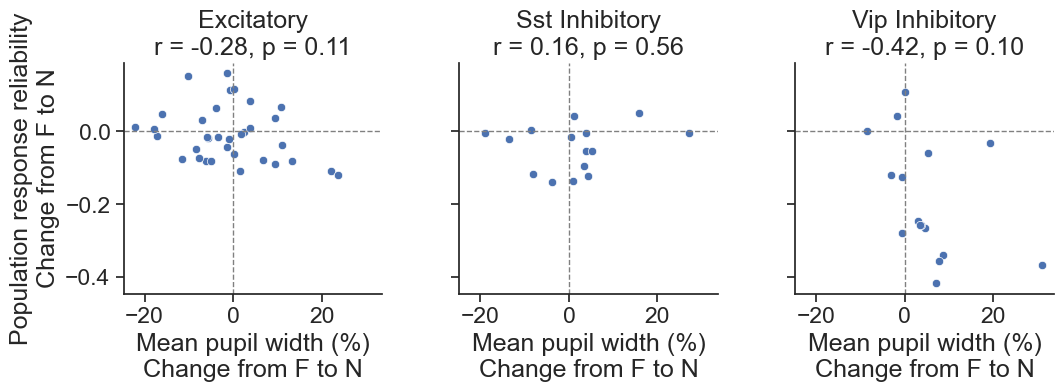

In [47]:
behavior_metric = 'mean_pupil_width_images'
behavior_label = 'Mean pupil width (%)'
suptitle = 'Change in neural activity vs change in pupil width from familiar to novel sessions'

cell_metric = 'mean_response_pref_image'
metric_label = 'Population image response'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, pupil_metrics_images, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric, 
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)



cell_metric = 'reliability_pref_image'
metric_label = 'Population response reliability'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, pupil_metrics_images, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric, 
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)

##### d-prime

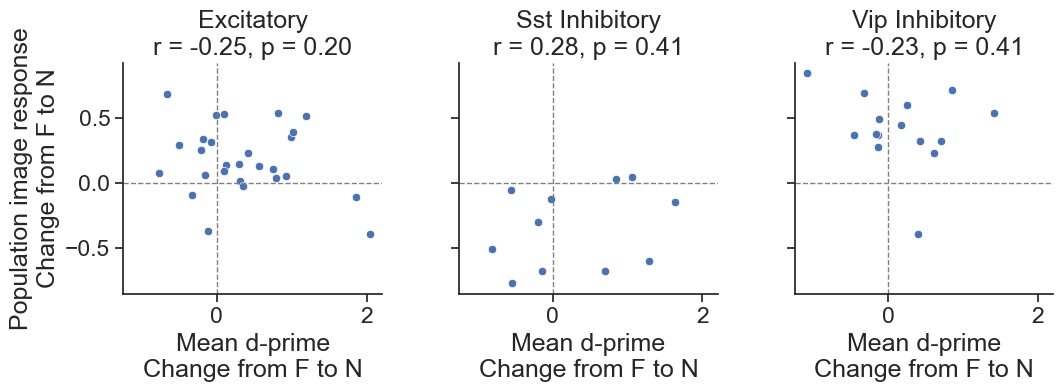

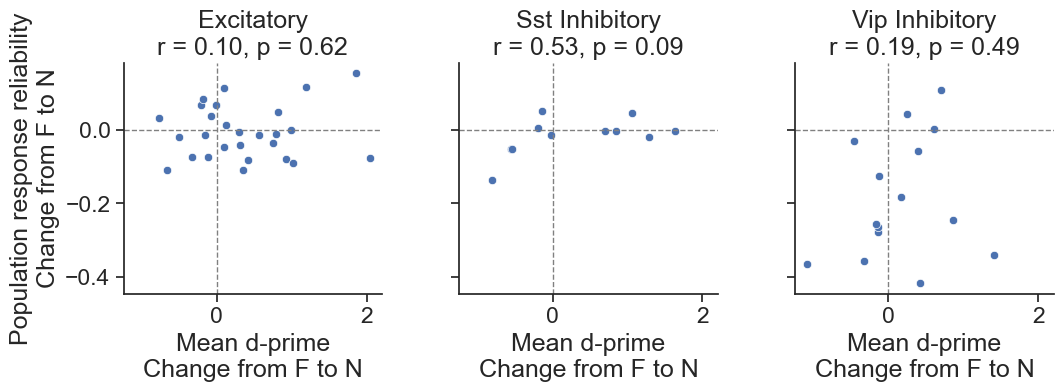

In [48]:
behavior_metric = 'mean_dprime_engaged'
behavior_label = 'Mean d-prime'
suptitle = 'Change in neural activity vs change in task performanced from familiar to novel sessions'

# metrics_table['mean_pupil_width_images'] = metrics_table['mean_pupil_width_images']*100


cell_metric = 'mean_response_pref_image'
metric_label = 'Population image response'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, behavior_stats_sdk, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric, 
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)



cell_metric = 'reliability_pref_image'
metric_label = 'Population response reliability'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, behavior_stats_sdk, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric, 
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)

In [49]:
#### For changes instead of images

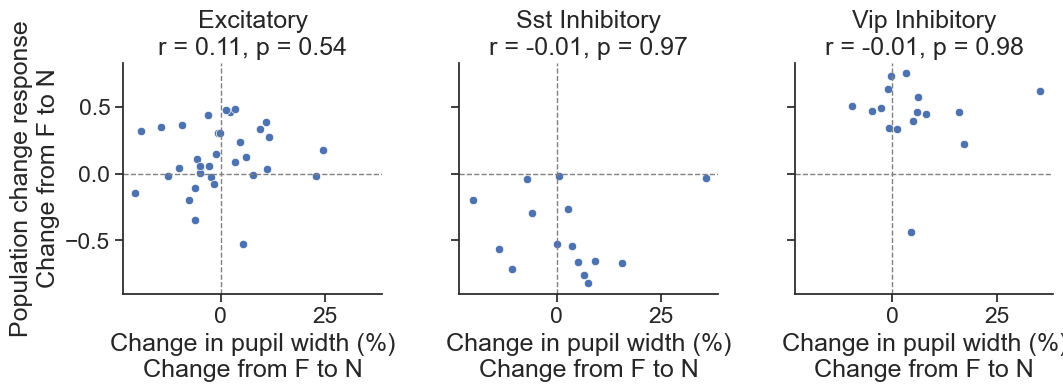

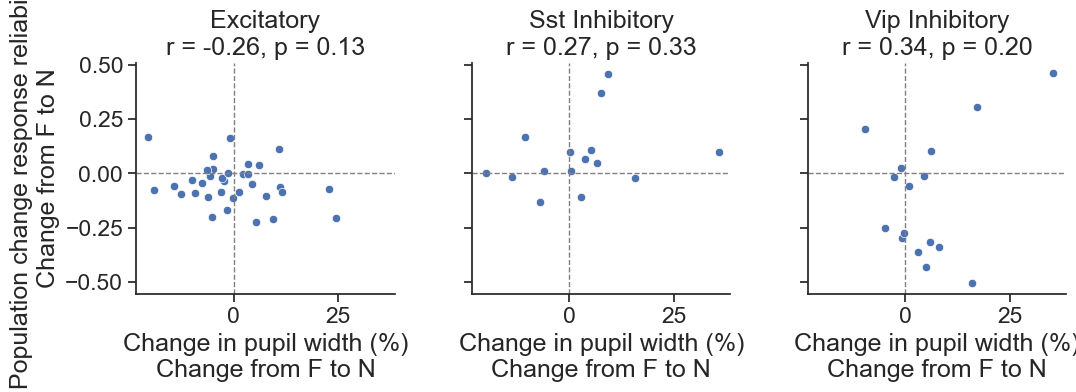

In [50]:

behavior_metric = 'mean_pupil_width_changes'
behavior_label = 'Change in pupil width (%)'

cell_metric = 'mean_response_changes'
metric_label = 'Population change response'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, pupil_metrics_changes, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric, 
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)



cell_metric = 'reliability_changes'
metric_label = 'Population change response reliability'

metric_data = ppf.get_change_in_behavior_and_average_cell_metric_across_mice(
    metrics_table, pupil_metrics_changes, platform_experiments,
    behavior_metric, cell_metric, avg_diff_per_cell=False)

ppf.plot_correlation_of_behavior_and_cell_metrics_delta(
    metric_data, behavior_metric, cell_metric, 
    metric_label=metric_label, behavior_label=behavior_label, suptitle=None,
    save_dir=save_dir)